# Librerias

In [1]:
import pandas as pd
import numpy as np
from kmodes.kprototypes import KPrototypes
import matplotlib.pyplot as plt

# Carga de la bbdd y reducción

## 1. Cargar csv

In [3]:
#cargar datos
df = pd.read_parquet("../data/df_limpiado_260420.parquet")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,contactado_campania_previa
id,,,,,,,,,,,,,,,,,,
1,59.0,administration,married,secondary,no,2343,yes,no,unknown,5,may,1042.0,1,NaN,0,sin_campania_previa,yes,0
2,56.0,administration,married,secondary,no,45,no,no,unknown,5,may,1467.0,1,NaN,0,sin_campania_previa,yes,0
3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389.0,1,NaN,0,sin_campania_previa,yes,0
4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579.0,1,NaN,0,sin_campania_previa,yes,0
5,54.0,administration,married,tertiary,no,184,no,no,unknown,5,may,673.0,2,NaN,0,sin_campania_previa,yes,0


In [5]:
# Nos quedamos con las variables que usaremos para segmentar
cols = ["age", "job", "marital", "education", "balance", "deposit", "housing", "loan"]

df_perfil = df[cols].copy()
df_perfil.head()

,age,job,marital,education,balance,deposit,housing,loan
id,,,,,,,,
1,59.0,administration,married,secondary,2343,yes,yes,no
2,56.0,administration,married,secondary,45,yes,no,no
3,41.0,technician,married,secondary,1270,yes,yes,no
4,55.0,services,married,secondary,2476,yes,yes,no
5,54.0,administration,married,tertiary,184,yes,no,no


## 2. Categorizar edad (tal vez ya está)

In [6]:
df_perfil["age_group"] = pd.cut(df_perfil["age"], bins=[0, 25, 35, 45, 55, 65, 120], labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"])

#Eliminamos la columna numérica original
df_perfil = df_perfil.drop(columns=["age"])

## 3. Convertir variables a 0 y 1 (tal vez ya está)

In [7]:
for col in ["deposit", "housing", "loan"]:
    df_perfil[col] = df_perfil[col].map({"yes": 1, "no": 0})

In [9]:
df_perfil = df_perfil.reset_index(drop=True)
df_perfil.head()

,job,marital,education,balance,deposit,housing,loan,age_group
0,administration,married,secondary,2343,1,1,0,56-65
1,administration,married,secondary,45,1,0,0,56-65
2,technician,married,secondary,1270,1,1,0,36-45
3,services,married,secondary,2476,1,1,0,46-55
4,administration,married,tertiary,184,1,0,0,46-55


# Perfil del cliente

## 1. Preparar datos para K‑Prototipos

In [10]:
#Dividir categóricas y numéricas
cat_cols = ["age_group", "job", "marital", "education"]
num_cols = ["deposit", "housing", "loan"]

#Matriz que usará K‑Prototipos, reordenado por tipo de variable
data_model = df_perfil[num_cols + cat_cols].copy()

#Guardamos los índices de las columnas categóricas, para saber que se trata como categórica
categorical_indices = [data_model.columns.get_loc(col) for col in cat_cols]

#Convertimos a numpy
X_proto = data_model.to_numpy()

## 2. Método del codo para elegir k

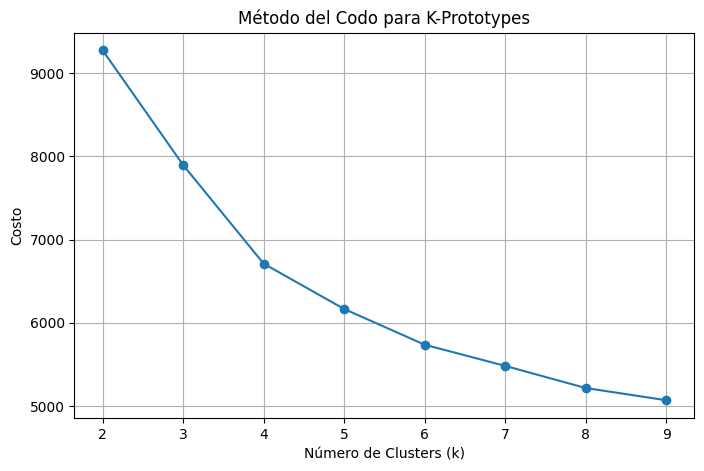

In [11]:
costs = []
ks = list(range(2, 10))

for k in ks:
    kproto = KPrototypes(n_clusters=k, init='Cao', verbose=0, random_state=42)
    clusters = kproto.fit_predict(X_proto, categorical=categorical_indices)
    costs.append(kproto.cost_)

# Graficar la curva del codo, el “codo” es donde la curva deja de bajar bruscamente, ese será k óptimo
plt.figure(figsize=(8, 5))
plt.plot(ks, costs, marker='o')
plt.title("Método del Codo para K-Prototypes")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Costo")
plt.grid(True)
plt.show()

## 3. Entrenar K‑Prototipos

In [12]:
#Entrenar K‑Prototipos
k_opt = 4

kproto = KPrototypes(n_clusters=k_opt, init='Cao', verbose=0, random_state=42)
clusters = kproto.fit_predict(X_proto, categorical=categorical_indices)

#Guardamos el cluster en el dataframe original
df_perfil["cluster"] = clusters

## 3. Ver los prototipos de cada cluster

In [13]:
#Prototipos (centros) de cada cluster
prototypes = kproto.cluster_centroids_

num_prototypes = prototypes[0]  # numéricas
cat_prototypes = prototypes[1]  # categóricas

print("Centros numéricos:\n", num_prototypes)
print("Centros categóricos:\n", cat_prototypes)

Centros numéricos:
 ['1.0' '0.0' '0.06529516994633273' '26-35' 'management' 'married'
 'secondary']
Centros categóricos:
 ['0.0' '0.0' '0.15915004336513444' '26-35' 'management' 'married'
 'secondary']


## 4. Perfil de productos por cluster

In [14]:
#Para identificar que cluster destaca por producto:
cluster_products = df_perfil.groupby("cluster")[["deposit","housing","loan"]].mean()

print(cluster_products)

         deposit  housing      loan
cluster                            
0            1.0      0.0  0.065295
1            0.0      0.0  0.159150
2            0.0      1.0  0.170988
3            1.0      1.0  0.136951


## 5. Perfil demográfico por cluster

In [15]:
#Distribución de age_group:
cluster_age = pd.crosstab(df_perfil["cluster"], df_perfil["age_group"], normalize="index")

print(cluster_age)

age_group      <=25     26-35     36-45     46-55     56-65       65+
cluster                                                              
0          0.074538  0.316339  0.204830  0.176208  0.137150  0.090936
1          0.022116  0.301821  0.274501  0.254987  0.115785  0.030789
2          0.021989  0.386282  0.345914  0.182146  0.063013  0.000656
3          0.036176  0.417571  0.317829  0.155556  0.065116  0.007752


In [16]:
#Distribución de job:
cluster_job = pd.crosstab(df_perfil["cluster"], df_perfil["job"], normalize="index")

print(cluster_job)

job      administration  blue-collar  entrepreneur  housemaid  management  \
cluster                                                                     
0              0.102564     0.081395      0.020871   0.025343    0.259392   
1              0.100173     0.140069      0.035559   0.044666    0.244579   
2              0.136856     0.262225      0.033804   0.014769    0.191008   
3              0.148320     0.224806      0.027390   0.012403    0.222739   

job       retired  self-employed  services   student  technician  unemployed  \
cluster                                                                        
0        0.138342       0.035480  0.054860  0.073643    0.150268    0.048301   
1        0.076756       0.044666  0.067216  0.025152    0.174328    0.032524   
2        0.020348       0.032163  0.117164  0.008861    0.162455    0.020020   
3        0.026873       0.035142  0.095607  0.011370    0.173643    0.020672   

job       unknown  
cluster            
0        0.00954

In [17]:
#Distribución de marital:
cluster_marital = pd.crosstab(df_perfil["cluster"], df_perfil["marital"], normalize="index")

print(cluster_marital)

marital  divorced   married    single
cluster                              
0        0.110614  0.521467  0.367919
1        0.117086  0.594970  0.287944
2        0.112570  0.625205  0.262225
3        0.128682  0.521447  0.349871


In [18]:
#Distribución de education:
cluster_education = pd.crosstab(df_perfil["cluster"], df_perfil["education"], normalize="index")

print(cluster_education)

education   primary  secondary  tertiary   unknown
cluster                                           
0          0.109123   0.421586  0.411747  0.057543
1          0.153946   0.456201  0.337381  0.052472
2          0.155235   0.563833  0.248113  0.032819
3          0.116279   0.535917  0.317313  0.030491


## 6. Conclusiones